# Interpretability Tradeoff Evaluation: FIGS Variants

**Six-block evaluation** of 5 FIGS (Fast Interpretable Greedy-tree Sums) variants across multiple datasets.

Analyses performed:
- **(A)** Arity comparison table — mean/std per (dataset, method, max_splits)
- **(B)** Arity reduction significance — pooled/per-dataset Wilcoxon, bootstrap CIs, Cohen's d
- **(C)** Accuracy equivalence — Bayesian ROPE analysis
- **(D)** Pareto frontier counting — methods on arity-accuracy frontier
- **(E)** Path length analysis — significance tests on tree depth
- **(F)** Cognitive complexity — path_length x arity for high-dimensional datasets

Data: per-fold cross-validation results for axis_aligned, random_oblique, unsigned_spectral, signed_spectral, and hard_threshold split strategies.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are in Colab's pre-installed set

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    # scipy: use 1.16.3 on Python>=3.11 (Colab), 1.15.3 on Python 3.10
    _scipy_ver = '1.16.3' if sys.version_info >= (3, 11) else '1.15.3'
    _pip(f'scipy=={_scipy_ver}')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter6_interpretabilit/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['metadata']['results_per_fold'])} per-fold results")

Loaded 90 per-fold results


## Configuration

All tunable parameters. `N_BOOTSTRAP` controls the number of bootstrap resamples for confidence intervals (higher = more precise but slower).

In [5]:
# --- Tunable parameters ---
# N_BOOTSTRAP: number of bootstrap resamples for CIs (original: 10_000)
N_BOOTSTRAP = 10_000  # full publication-quality setting

ROPE = 0.01  # region of practical equivalence for balanced accuracy
METHODS = ["axis_aligned", "random_oblique", "unsigned_spectral", "signed_spectral", "hard_threshold"]
MAX_SPLITS_VALUES = [5, 10, 20]
HIGH_DIM_DATASETS = ["jannis", "miniboone", "higgs_small"]
RNG = np.random.default_rng(42)

## Data Preparation

Load per-fold results into a DataFrame and create a unified `performance` metric (balanced_accuracy for classification, r2 for regression).

In [6]:
results_per_fold = data["metadata"]["results_per_fold"]
df = pd.DataFrame(results_per_fold)
print(f"DataFrame shape: {df.shape}")
print(f"Datasets: {sorted(df['dataset'].unique())}")
print(f"Methods: {sorted(df['method'].unique())}")
print(f"Max splits: {sorted(df['max_splits'].unique())}")

# Validate expected shape
n_datasets = df["dataset"].nunique()
n_methods = df["method"].nunique()
n_splits = df["max_splits"].nunique()
n_folds = df.groupby(["dataset", "method", "max_splits"]).size().max()
print(f"Grid: {n_datasets} datasets x {n_methods} methods x {n_splits} max_splits x {n_folds} folds = {len(df)} rows")

# Create unified performance metric: balanced_accuracy for classification, r2 for regression
df["performance"] = df["balanced_accuracy"]
if "r2" in df.columns:
    regression_mask = df["balanced_accuracy"].isna() & df["r2"].notna()
    df.loc[regression_mask, "performance"] = df.loc[regression_mask, "r2"]
    print(f"Performance column: {df['performance'].notna().sum()} non-null "
          f"({regression_mask.sum()} from r2, {(~regression_mask & df['performance'].notna()).sum()} from balanced_accuracy)")
else:
    print(f"Performance column: {df['performance'].notna().sum()} non-null (all from balanced_accuracy)")

df.head()

DataFrame shape: (90, 14)
Datasets: ['adult', 'miniboone']
Methods: ['axis_aligned', 'hard_threshold', 'random_oblique', 'signed_spectral', 'unsigned_spectral']
Max splits: [np.int64(5), np.int64(10), np.int64(20)]
Grid: 2 datasets x 5 methods x 3 max_splits x 3 folds = 90 rows
Performance column: 90 non-null (all from balanced_accuracy)


,dataset,method,max_splits,fold,n_train,n_test,n_features,task_type,balanced_accuracy,auc,total_splits,avg_split_arity,avg_path_length,fit_time_s,performance
0,adult,axis_aligned,5,0,26048,6513,6,classification,0.582035,0.775906,5,1.0,2.6667,0.089,0.582035
1,adult,axis_aligned,5,1,26049,6512,6,classification,0.575073,0.769251,5,1.0,2.6667,0.042,0.575073
2,adult,axis_aligned,5,2,26049,6512,6,classification,0.587727,0.788450,5,1.0,2.6667,0.042,0.587727
3,adult,axis_aligned,10,0,26048,6513,6,classification,0.675938,0.805819,10,1.0,3.9091,0.095,0.675938
4,adult,axis_aligned,10,1,26049,6512,6,classification,0.660420,0.802632,10,1.0,3.9091,0.095,0.660420


## Utility Functions

Statistical helpers: Wilcoxon signed-rank test, bootstrap confidence intervals, Cohen's d effect size, Bayesian ROPE analysis, and pairwise comparison driver.

In [7]:
def _nanfloat(v):
    """Convert NaN/Inf to None for JSON-safe output."""
    if v is None or (isinstance(v, float) and (math.isnan(v) or math.isinf(v))):
        return None
    return float(v)


def safe_wilcoxon(x, y):
    """Wilcoxon signed-rank test with NaN filtering and fallback for constant differences."""
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    diff = x - y
    nonzero = diff[diff != 0]
    if len(nonzero) < 2:
        return {"W": None, "p": 1.0, "n_pairs": int(len(x)), "n_nonzero": int(len(nonzero))}
    try:
        res = stats.wilcoxon(x, y, alternative="two-sided")
        return {"W": float(res.statistic), "p": float(res.pvalue), "n_pairs": int(len(x)), "n_nonzero": int(len(nonzero))}
    except ValueError:
        return {"W": None, "p": 1.0, "n_pairs": int(len(x)), "n_nonzero": int(len(nonzero))}


def bootstrap_ci(diffs, n_boot=N_BOOTSTRAP, alpha=0.05):
    """Bootstrap 95% CI on mean difference, dropping NaN."""
    diffs = diffs[~np.isnan(diffs)]
    if len(diffs) == 0:
        return {"mean": None, "ci_lo": None, "ci_hi": None, "n_boot": n_boot}
    means = np.array([RNG.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {"mean": float(diffs.mean()), "ci_lo": float(lo), "ci_hi": float(hi), "n_boot": n_boot}


def cohens_d(x, y):
    """Cohen's d with bootstrap 95% CI, dropping NaN pairs."""
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) < 2:
        return {"d": None, "ci_lo": None, "ci_hi": None}
    diff = x - y
    pooled_std = np.sqrt((np.var(x, ddof=1) + np.var(y, ddof=1)) / 2)
    if pooled_std < 1e-12:
        return {"d": 0.0, "ci_lo": 0.0, "ci_hi": 0.0}
    d = diff.mean() / pooled_std
    ds = []
    for _ in range(N_BOOTSTRAP):
        idx = RNG.integers(0, len(x), size=len(x))
        bx, by = x[idx], y[idx]
        ps = np.sqrt((np.var(bx, ddof=1) + np.var(by, ddof=1)) / 2)
        if ps > 1e-12:
            ds.append((bx - by).mean() / ps)
    ds = np.array(ds)
    if len(ds) == 0:
        return {"d": float(d), "ci_lo": float(d), "ci_hi": float(d)}
    lo, hi = np.percentile(ds, [2.5, 97.5])
    return {"d": float(d), "ci_lo": float(lo), "ci_hi": float(hi)}


def bayesian_sign_test_rope(x, y, rope=ROPE):
    """Bayesian sign test with ROPE: fraction of differences in [-rope, +rope], positive, negative."""
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    diff = x - y
    n = len(diff)
    if n == 0:
        return {"p_equivalent": None, "p_method1_better": None, "p_method2_better": None, "rope": rope, "n": 0}
    n_equiv = int(np.sum(np.abs(diff) < rope))
    n_pos = int(np.sum(diff >= rope))
    n_neg = int(np.sum(diff <= -rope))
    return {
        "p_equivalent": round(n_equiv / n, 4),
        "p_method1_better": round(n_pos / n, 4),
        "p_method2_better": round(n_neg / n, 4),
        "rope": rope,
        "n": n,
    }


def pairwise_comparison(df, method1, method2, metric, datasets=None):
    """Run pooled and per-dataset Wilcoxon, bootstrap CI, Cohen's d on a metric."""
    sub = df if datasets is None else df[df["dataset"].isin(datasets)]
    m1 = sub[sub["method"] == method1].sort_values(["dataset", "max_splits", "fold"])[metric].values
    m2 = sub[sub["method"] == method2].sort_values(["dataset", "max_splits", "fold"])[metric].values
    if len(m1) != len(m2) or len(m1) == 0:
        print(f"  Warning: Mismatched lengths for {method1} vs {method2} on {metric}: {len(m1)} vs {len(m2)}")
        return {}
    result = {
        "pooled_wilcoxon": safe_wilcoxon(m1, m2),
        "bootstrap_ci_mean_diff": bootstrap_ci(m1 - m2),
        "cohens_d": cohens_d(m1, m2),
    }
    per_ds = {}
    ds_list = sorted(sub["dataset"].unique())
    for ds in ds_list:
        ds_sub = sub[sub["dataset"] == ds]
        v1 = ds_sub[ds_sub["method"] == method1].sort_values(["max_splits", "fold"])[metric].values
        v2 = ds_sub[ds_sub["method"] == method2].sort_values(["max_splits", "fold"])[metric].values
        if len(v1) == len(v2) and len(v1) > 0:
            per_ds[ds] = safe_wilcoxon(v1, v2)
    result["per_dataset_wilcoxon"] = per_ds
    return result


def accuracy_equivalence(df, method1, method2):
    """Accuracy equivalence: Wilcoxon, Bayesian ROPE, bootstrap CI."""
    m1 = df[df["method"] == method1].sort_values(["dataset", "max_splits", "fold"])["performance"].values
    m2 = df[df["method"] == method2].sort_values(["dataset", "max_splits", "fold"])["performance"].values
    if len(m1) != len(m2) or len(m1) == 0:
        return {}
    return {
        "wilcoxon": safe_wilcoxon(m1, m2),
        "bayesian_rope": bayesian_sign_test_rope(m1, m2, rope=ROPE),
        "bootstrap_ci_mean_diff": bootstrap_ci(m1 - m2),
        "cohens_d": cohens_d(m1, m2),
        "mean_performance_method1": round(float(np.nanmean(m1)), 6),
        "mean_performance_method2": round(float(np.nanmean(m2)), 6),
    }

print("Utility functions defined.")

Utility functions defined.


## Analysis A: Arity Comparison Table

Mean and standard deviation of split arity per (dataset, method, max_splits) combination.

In [8]:
print("=== Analysis A: Arity Comparison Table ===")
arity_table = {}
for (ds, method, ms), grp in df.groupby(["dataset", "method", "max_splits"]):
    key = f"{ds}__{method}__ms{ms}"
    arity_table[key] = {
        "dataset": ds,
        "method": method,
        "max_splits": int(ms),
        "arity_mean": round(float(grp["avg_split_arity"].mean()), 4),
        "arity_std": round(float(grp["avg_split_arity"].std()), 4),
        "n_folds": int(len(grp)),
    }
print(f"Computed arity stats for {len(arity_table)} cells")

# Show summary as DataFrame
arity_df = pd.DataFrame(arity_table.values())
print(arity_df.pivot_table(values="arity_mean", index="method", columns="max_splits", aggfunc="mean").round(3).to_string())

=== Analysis A: Arity Comparison Table ===
Computed arity stats for 30 cells
max_splits             5       10      20
method                                   
axis_aligned        1.000   1.000   1.000
hard_threshold      9.900  12.750  12.483
random_oblique      3.433   3.050   3.183
signed_spectral     7.500   6.133   6.592
unsigned_spectral  13.900  14.167  12.767


## Analysis B: Arity Reduction Significance

Pairwise Wilcoxon tests, bootstrap CIs, and Cohen's d on split arity for key method comparisons.

In [9]:
print("=== Analysis B: Arity Reduction Significance ===")
arity_comparisons = {
    "unsigned_spectral_vs_random_oblique": ("unsigned_spectral", "random_oblique"),
    "unsigned_spectral_vs_hard_threshold": ("unsigned_spectral", "hard_threshold"),
    "signed_spectral_vs_random_oblique": ("signed_spectral", "random_oblique"),
}
arity_sig_results = {}
for label, (m1, m2) in arity_comparisons.items():
    print(f"  Comparing {m1} vs {m2} on avg_split_arity")
    arity_sig_results[label] = pairwise_comparison(df, m1, m2, "avg_split_arity")
    pw = arity_sig_results[label].get("pooled_wilcoxon", {})
    cd = arity_sig_results[label].get("cohens_d", {})
    print(f"    Wilcoxon p={pw.get('p', 'N/A'):.4g}, Cohen's d={cd.get('d', 'N/A')}")

=== Analysis B: Arity Reduction Significance ===
  Comparing unsigned_spectral vs random_oblique on avg_split_arity


    Wilcoxon p=0.07773, Cohen's d=1.2105865099695652
  Comparing unsigned_spectral vs hard_threshold on avg_split_arity


    Wilcoxon p=0.001161, Cohen's d=0.16499571326232382
  Comparing signed_spectral vs random_oblique on avg_split_arity


    Wilcoxon p=0.07773, Cohen's d=0.9827245423717422


## Analysis C: Accuracy Equivalence

Test whether spectral methods maintain accuracy parity with baselines using Wilcoxon tests and Bayesian ROPE analysis.

In [10]:
print("=== Analysis C: Accuracy Equivalence ===")
acc_comparisons = {
    "unsigned_spectral_vs_random_oblique": ("unsigned_spectral", "random_oblique"),
    "unsigned_spectral_vs_hard_threshold": ("unsigned_spectral", "hard_threshold"),
    "unsigned_spectral_vs_axis_aligned": ("unsigned_spectral", "axis_aligned"),
}
acc_equiv_results = {}
for label, (m1, m2) in acc_comparisons.items():
    print(f"  Comparing {m1} vs {m2} on performance")
    acc_equiv_results[label] = accuracy_equivalence(df, m1, m2)
    res = acc_equiv_results[label]
    wil = res.get("wilcoxon", {})
    rope = res.get("bayesian_rope", {})
    print(f"    Wilcoxon p={wil.get('p', 'N/A'):.4g}, ROPE P(equiv)={rope.get('p_equivalent', 'N/A')}")
    print(f"    Mean perf: {m1}={res.get('mean_performance_method1', 'N/A')}, {m2}={res.get('mean_performance_method2', 'N/A')}")

=== Analysis C: Accuracy Equivalence ===
  Comparing unsigned_spectral vs random_oblique on performance


    Wilcoxon p=0.04317, ROPE P(equiv)=0.2222
    Mean perf: unsigned_spectral=0.796275, random_oblique=0.78391
  Comparing unsigned_spectral vs hard_threshold on performance


    Wilcoxon p=0.03856, ROPE P(equiv)=0.7222
    Mean perf: unsigned_spectral=0.796275, hard_threshold=0.785563
  Comparing unsigned_spectral vs axis_aligned on performance


    Wilcoxon p=2.289e-05, ROPE P(equiv)=0.0556
    Mean perf: unsigned_spectral=0.796275, axis_aligned=0.75639


## Analysis D: Pareto Frontier

Identify which methods lie on the Pareto frontier of (lower arity, higher accuracy) across all dataset/max_splits settings.

In [11]:
print("=== Analysis D: Pareto Frontier ===")
summary = df.groupby(["dataset", "method", "max_splits"]).agg(
    arity_mean=("avg_split_arity", "mean"),
    accuracy_mean=("performance", "mean"),
).reset_index()

datasets = sorted(df["dataset"].unique())
frontier_counts = {m: 0 for m in METHODS}
best_tradeoff_counts = {m: 0 for m in METHODS}
n_settings = 0
per_setting_details = {}

for ds in datasets:
    for ms in MAX_SPLITS_VALUES:
        setting = f"{ds}__ms{ms}"
        sub = summary[(summary["dataset"] == ds) & (summary["max_splits"] == ms)]
        if len(sub) == 0:
            continue
        n_settings += 1
        on_frontier = []
        for _, row in sub.iterrows():
            dominated = False
            for _, other in sub.iterrows():
                if (other["arity_mean"] < row["arity_mean"] and
                        other["accuracy_mean"] > row["accuracy_mean"]):
                    dominated = True
                    break
            if not dominated:
                on_frontier.append(row["method"])
                frontier_counts[row["method"]] += 1
        frontier_non_aa = [m for m in on_frontier if m != "axis_aligned"]
        best = None
        if frontier_non_aa:
            best = min(frontier_non_aa,
                       key=lambda m: sub[sub["method"] == m]["arity_mean"].values[0])
            best_tradeoff_counts[best] += 1
        per_setting_details[setting] = {"on_frontier": on_frontier, "best_tradeoff": best}

frontier_table = {}
for m in METHODS:
    frontier_table[m] = {
        "count": frontier_counts[m],
        "percentage": round(100 * frontier_counts[m] / n_settings, 1) if n_settings else 0,
        "best_tradeoff_count": best_tradeoff_counts[m],
        "best_tradeoff_pct": round(100 * best_tradeoff_counts[m] / n_settings, 1) if n_settings else 0,
    }

pareto_results = {"n_settings": n_settings, "frontier_table": frontier_table, "per_setting_details": per_setting_details}

print(f"Pareto analysis over {n_settings} settings")
for m in METHODS:
    ft = frontier_table[m]
    print(f"  {m}: frontier {ft['count']}/{n_settings} ({ft['percentage']}%), best_tradeoff {ft['best_tradeoff_count']}/{n_settings}")

=== Analysis D: Pareto Frontier ===
Pareto analysis over 6 settings
  axis_aligned: frontier 6/6 (100.0%), best_tradeoff 0/6
  random_oblique: frontier 4/6 (66.7%), best_tradeoff 3/6
  unsigned_spectral: frontier 5/6 (83.3%), best_tradeoff 2/6
  signed_spectral: frontier 4/6 (66.7%), best_tradeoff 0/6
  hard_threshold: frontier 4/6 (66.7%), best_tradeoff 1/6


## Analysis E: Path Length

Descriptive statistics and significance tests on average tree path length across methods.

In [12]:
print("=== Analysis E: Path Length Analysis ===")
path_table = {}
for (ds, method, ms), grp in df.groupby(["dataset", "method", "max_splits"]):
    key = f"{ds}__{method}__ms{ms}"
    path_table[key] = {
        "dataset": ds, "method": method, "max_splits": int(ms),
        "path_length_mean": round(float(grp["avg_path_length"].mean()), 4),
        "path_length_std": round(float(grp["avg_path_length"].std()), 4),
    }

path_comparisons = {
    "unsigned_spectral_vs_random_oblique": ("unsigned_spectral", "random_oblique"),
    "unsigned_spectral_vs_axis_aligned": ("unsigned_spectral", "axis_aligned"),
    "unsigned_spectral_vs_hard_threshold": ("unsigned_spectral", "hard_threshold"),
}
path_sig_tests = {}
for label, (m1, m2) in path_comparisons.items():
    print(f"  Path length: {m1} vs {m2}")
    path_sig_tests[label] = pairwise_comparison(df, m1, m2, "avg_path_length")
    pw = path_sig_tests[label].get("pooled_wilcoxon", {})
    print(f"    Wilcoxon p={pw.get('p', 'N/A'):.4g}")

path_results = {"descriptive": path_table, "significance_tests": path_sig_tests}

=== Analysis E: Path Length Analysis ===
  Path length: unsigned_spectral vs random_oblique


    Wilcoxon p=0.007632
  Path length: unsigned_spectral vs axis_aligned


    Wilcoxon p=0.005363
  Path length: unsigned_spectral vs hard_threshold


    Wilcoxon p=0.8122


## Analysis F: Cognitive Complexity

Cognitive complexity = path_length x arity measures total features inspected per prediction. Focus on high-dimensional datasets where interpretability gains matter most.

In [13]:
print("=== Analysis F: Cognitive Complexity ===")
df_cc = df.copy()
df_cc["cognitive_complexity"] = df_cc["avg_path_length"] * df_cc["avg_split_arity"]

# Descriptive stats
cc_table = {}
for (ds, method, ms), grp in df_cc.groupby(["dataset", "method", "max_splits"]):
    key = f"{ds}__{method}__ms{ms}"
    cc_table[key] = {
        "dataset": ds, "method": method, "max_splits": int(ms),
        "cc_mean": round(float(grp["cognitive_complexity"].mean()), 4),
        "cc_std": round(float(grp["cognitive_complexity"].std()), 4),
    }

# Focus on high-dimensional datasets present in our data
available_high_dim = [d for d in HIGH_DIM_DATASETS if d in df_cc["dataset"].unique()]
high_dim = df_cc[df_cc["dataset"].isin(available_high_dim)]

high_dim_tests = {}
if len(available_high_dim) > 0:
    us_vals = high_dim[high_dim["method"] == "unsigned_spectral"].sort_values(
        ["dataset", "max_splits", "fold"])["cognitive_complexity"].values
    ro_vals = high_dim[high_dim["method"] == "random_oblique"].sort_values(
        ["dataset", "max_splits", "fold"])["cognitive_complexity"].values

    if len(us_vals) == len(ro_vals) and len(us_vals) > 0:
        high_dim_tests["pooled_wilcoxon"] = safe_wilcoxon(us_vals, ro_vals)
        high_dim_tests["bootstrap_ci"] = bootstrap_ci(us_vals - ro_vals)
        high_dim_tests["cohens_d"] = cohens_d(us_vals, ro_vals)
        ro_mean = ro_vals.mean()
        us_mean = us_vals.mean()
        if ro_mean > 0:
            pct_reduction = (ro_mean - us_mean) / ro_mean * 100
        else:
            pct_reduction = 0.0
        high_dim_tests["pct_reduction"] = round(float(pct_reduction), 2)
        high_dim_tests["us_mean_cc"] = round(float(us_mean), 4)
        high_dim_tests["ro_mean_cc"] = round(float(ro_mean), 4)
        print(f"  High-dim CC reduction: {pct_reduction:.1f}%")
        print(f"  unsigned_spectral mean CC: {us_mean:.4f}, random_oblique mean CC: {ro_mean:.4f}")
else:
    print("  No high-dimensional datasets in demo subset")

cc_results = {
    "descriptive": cc_table,
    "high_dim_analysis": {"datasets": available_high_dim, "pooled_tests": high_dim_tests},
}

# Collect all analyses
analyses = {
    "A_arity_table": arity_table,
    "B_arity_significance": arity_sig_results,
    "C_accuracy_equivalence": acc_equiv_results,
    "D_pareto": pareto_results,
    "E_path_length": path_results,
    "F_cognitive_complexity": cc_results,
}
print("\nAll 6 analyses completed.")

=== Analysis F: Cognitive Complexity ===


  High-dim CC reduction: -637.9%
  unsigned_spectral mean CC: 92.0481, random_oblique mean CC: 12.4742

All 6 analyses completed.


## Results Summary & Visualization

Key findings table and plots: (1) mean arity by method, (2) Pareto frontier percentages, (3) arity vs accuracy scatterplot.

KEY RESULTS SUMMARY
Arity unsigned_spectral_vs_random_oblique:
  Wilcoxon p=0.07773, Cohen's d=1.211
Arity unsigned_spectral_vs_hard_threshold:
  Wilcoxon p=0.001161, Cohen's d=0.165
Arity signed_spectral_vs_random_oblique:
  Wilcoxon p=0.07773, Cohen's d=0.983
Accuracy unsigned_spectral_vs_random_oblique:
  Wilcoxon p=0.04317, ROPE P(equiv)=0.2222
Accuracy unsigned_spectral_vs_hard_threshold:
  Wilcoxon p=0.03856, ROPE P(equiv)=0.7222
Accuracy unsigned_spectral_vs_axis_aligned:
  Wilcoxon p=2.289e-05, ROPE P(equiv)=0.0556

Pareto frontier (over 6 settings):
  axis_aligned: 100.0% on frontier
  random_oblique: 66.7% on frontier
  unsigned_spectral: 83.3% on frontier
  signed_spectral: 66.7% on frontier
  hard_threshold: 66.7% on frontier

Cognitive complexity reduction (high-dim): -637.9%


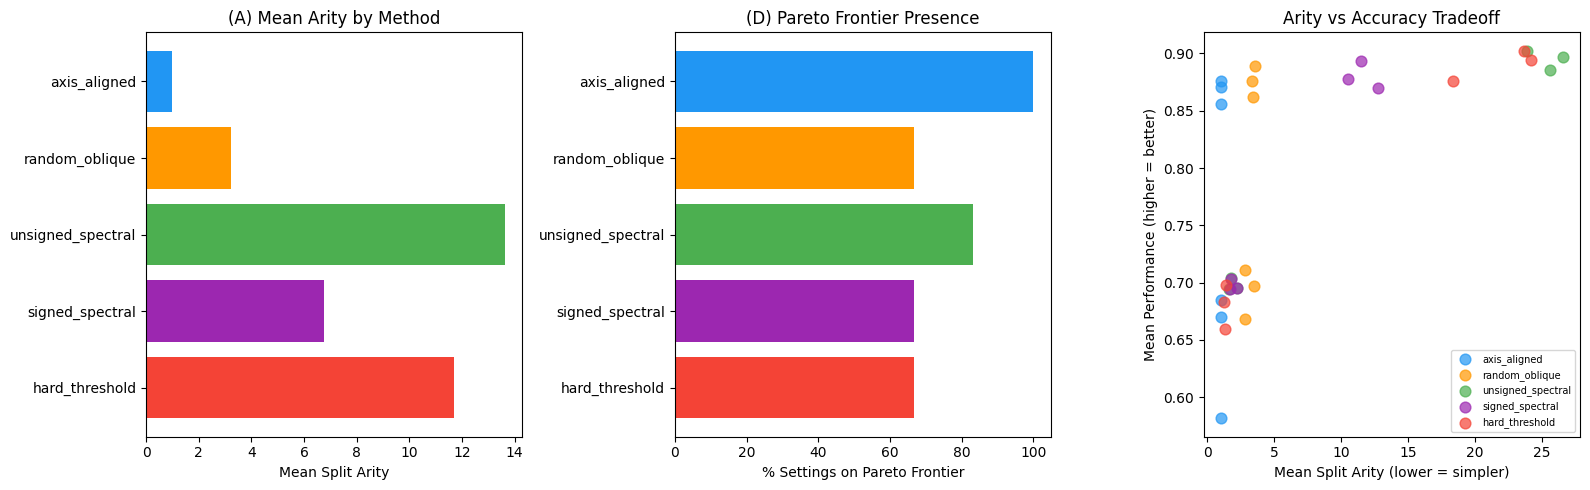


Figure saved to interpretability_tradeoff.png


In [14]:
# --- Key Results Table ---
print("=" * 70)
print("KEY RESULTS SUMMARY")
print("=" * 70)

# Arity significance
for label, res in arity_sig_results.items():
    pw = res.get("pooled_wilcoxon", {})
    cd = res.get("cohens_d", {})
    print(f"Arity {label}:")
    print(f"  Wilcoxon p={pw.get('p', 'N/A'):.4g}, Cohen's d={cd.get('d', 'N/A'):.3f}")

# Accuracy equivalence
for label, res in acc_equiv_results.items():
    wil = res.get("wilcoxon", {})
    rope = res.get("bayesian_rope", {})
    print(f"Accuracy {label}:")
    print(f"  Wilcoxon p={wil.get('p', 'N/A'):.4g}, ROPE P(equiv)={rope.get('p_equivalent', 'N/A')}")

# Pareto
print(f"\nPareto frontier (over {pareto_results['n_settings']} settings):")
for m in METHODS:
    ft = frontier_table[m]
    print(f"  {m}: {ft['percentage']}% on frontier")

# CC reduction
if high_dim_tests:
    print(f"\nCognitive complexity reduction (high-dim): {high_dim_tests.get('pct_reduction', 0):.1f}%")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Mean arity by method (averaged across datasets and max_splits)
mean_arity = df.groupby("method")["avg_split_arity"].mean().reindex(METHODS)
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']
available_methods = [m for m in METHODS if m in mean_arity.index]
available_colors = [colors[METHODS.index(m)] for m in available_methods]
axes[0].barh(available_methods, mean_arity[available_methods], color=available_colors)
axes[0].set_xlabel("Mean Split Arity")
axes[0].set_title("(A) Mean Arity by Method")
axes[0].invert_yaxis()

# Plot 2: Pareto frontier percentage
pct_vals = [frontier_table[m]["percentage"] for m in available_methods]
axes[1].barh(available_methods, pct_vals, color=available_colors)
axes[1].set_xlabel("% Settings on Pareto Frontier")
axes[1].set_title("(D) Pareto Frontier Presence")
axes[1].invert_yaxis()
axes[1].set_xlim(0, 105)

# Plot 3: Arity vs Accuracy scatter
for i, m in enumerate(available_methods):
    m_data = summary[summary["method"] == m]
    axes[2].scatter(m_data["arity_mean"], m_data["accuracy_mean"],
                    label=m, alpha=0.7, s=60, color=colors[METHODS.index(m)])
axes[2].set_xlabel("Mean Split Arity (lower = simpler)")
axes[2].set_ylabel("Mean Performance (higher = better)")
axes[2].set_title("Arity vs Accuracy Tradeoff")
axes[2].legend(fontsize=7, loc="best")

plt.tight_layout()
plt.savefig("interpretability_tradeoff.png", dpi=100, bbox_inches="tight")
plt.show()
print("\nFigure saved to interpretability_tradeoff.png")